<a href="https://colab.research.google.com/github/CarolaineRangel/Retencao-por-tipo-de-documento/blob/main/Reten%C3%A7%C3%A3o_por_tipo_de_documento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install google-cloud-bigquery
from google.colab import auth
auth.authenticate_user()


In [ ]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install lifelines
from lifelines import KaplanMeierFitter
project_id = "name_projeto"
client = bigquery.Client(project=project_id)

query1 = """

select
distinct
company_id,
company_name,
idi_app,
company_lifecycle_stage,
cohort_month,
churn_date,
document_type,
ativo,
avg_gmv,
is_icp,
count_first_30_days,
faixa_pedidos_30,
active_days_first_30,
plan_name,
address_state,
tipo_atendimento,
tipo_atendimento_v2,
business_model

from `customer_experience.sales_retention_study`
"""
query_job = client.query(query1)
df = query_job.to_dataframe()
df.head()


<ipython-input-138-e75c2bc8e154>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["tempo_ate_churn"] = np.where(


Total de clientes considerados: 20655


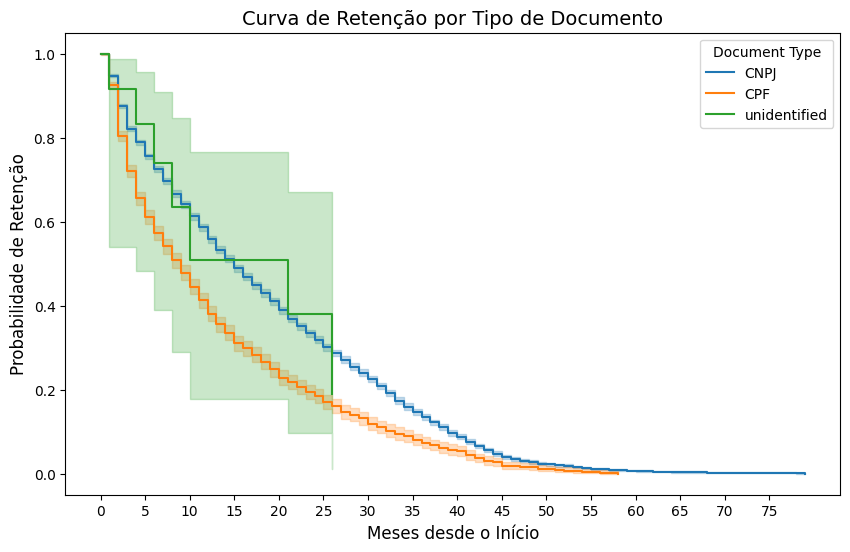

In [ ]:
# Converter churn_date e cohort_month para datetime
df["cohort_month"] = pd.to_datetime(df["cohort_month"])
df["churn_date"] = pd.to_datetime(df["churn_date"])
df["current_date"] = pd.Timestamp.today().normalize()  # Apenas data, sem horário

# Garantir que não há valores NaN em company_lifecycle_stage
df = df.dropna(subset=["company_lifecycle_stage"])

# Aplicar a lógica para calcular tempo_ate_churn corretamente
df["tempo_ate_churn"] = np.where(
    df["company_lifecycle_stage"] == "customer",
    (df["current_date"] - df["cohort_month"]).dt.days / 30,  # Tempo até hoje (em meses)
    np.where(
        df["churn_date"].notna(),  # Verifica se churn_date não é NaN
        (df["churn_date"] - df["cohort_month"]).dt.days / 30,  # Tempo até churn (em meses)
        np.nan  # Se churn_date for NaN, deixa NaN
    )
)

# Remover valores NaN antes do modelo
df_kmf = df.dropna(subset=["tempo_ate_churn", "ativo"]).copy()

# Garantir que os tipos de dados estão corretos
df_kmf["tempo_ate_churn"] = df_kmf["tempo_ate_churn"].astype(int)  # Transformar em inteiro
df_kmf["ativo"] = df_kmf["ativo"].astype(int)  # Garantir que é 0 ou 1

# Filtrar para considerar apenas tempos positivos ou zero
df_kmf = df_kmf[df_kmf["tempo_ate_churn"] >= 0]

# Verificar se há dados suficientes antes de rodar o modelo
print(f"Total de clientes considerados: {len(df_kmf)}")

if len(df_kmf) > 0:
    plt.figure(figsize=(10, 6))

    # Criar e ajustar um modelo Kaplan-Meier para cada document_type
    for doc_type, df_group in df_kmf.groupby("document_type"):
        kmf = KaplanMeierFitter()
        kmf.fit(df_group["tempo_ate_churn"], event_observed=df_group["ativo"], label=f"{doc_type}")

        # Plotar a curva de retenção para cada document_type
        kmf.plot_survival_function()

    # Ajustar rótulos e título
    plt.title("Curva de Retenção por Tipo de Documento", fontsize=14)
    plt.xlabel("Meses desde o Início", fontsize=12)
    plt.ylabel("Probabilidade de Retenção", fontsize=12)

    # Adicionar legenda para identificar os diferentes tipos de documentos
    plt.legend(title="Document Type", fontsize=10)

    # Definir rótulos no eixo X a cada 5 meses
    max_x = df_kmf["tempo_ate_churn"].max()
    if max_x > 0:
        plt.xticks(np.arange(0, max_x + 1, step=5))

    plt.show()
else:
    print("Erro: Nenhum dado disponível para análise.")

<lifelines.CoxPHFitter: fitted with 27028 total observations, 9920 right-censored observations>
             duration col = 'tempo_ate_churn'
                event col = 'ativo'
      baseline estimation = breslow
   number of observations = 27028
number of events observed = 17108
   partial log-likelihood = -155453.72
         time fit was run = 2025-04-03 21:14:32 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
CPF           0.43      1.53      0.02            0.39            0.47                1.48                1.60
Unidentified  0.64      1.90      0.05            0.54            0.74                1.71                2.11

              cmp to     z      p  -log2(p)
covariate                                  
CPF             0.00 21.20 <0.005    328.91
Unidentified    0.00 11.99 <0.005    107.54
---
Concordance = 0.54
Partial AIC = 310911.44
log-likelihood ratio test = 504.26 on 2 df
-log2(p) of ll-ratio test = 363.75

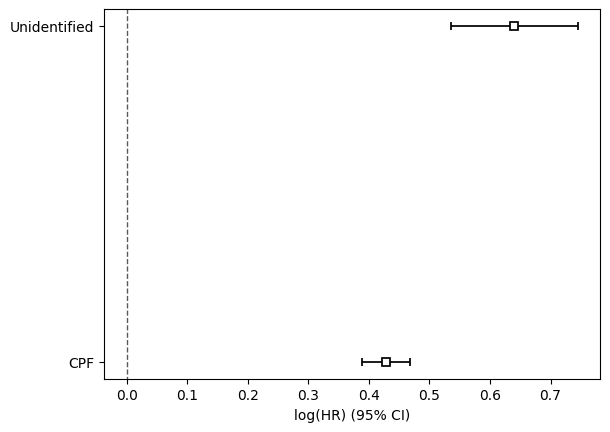

In [ ]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter

# Configurar BigQuery
project_id = "name_projeto"
client = bigquery.Client(project=project_id)

# Query para extrair os dados
query = """
SELECT DISTINCT
    company_id,
    company_name,
    company_lifecycle_stage,
    cohort_month,
    churn_date,
    document_type,
    ativo
FROM `customer_experience.sales_retention_study`
"""
df = client.query(query).to_dataframe()

# Converter datas para datetime
df["cohort_month"] = pd.to_datetime(df["cohort_month"])
df["churn_date"] = pd.to_datetime(df["churn_date"])
df["current_date"] = pd.Timestamp.today().normalize()

# Calcular tempo até churn (em meses)
df["tempo_ate_churn"] = np.where(
    df["company_lifecycle_stage"] == "customer",
    (df["current_date"] - df["cohort_month"]).dt.days / 30,
    np.where(
        df["churn_date"].notna(),
        (df["churn_date"] - df["cohort_month"]).dt.days / 30,
        np.nan
    )
)

# Remover valores NaN
df = df.dropna(subset=["tempo_ate_churn", "ativo", "document_type"])

# Converter variável categórica para dummies e definir CNPJ como referência
df = pd.get_dummies(df, columns=["document_type"], drop_first=False)
df.rename(columns={
    "document_type_CPF": "CPF",
    "document_type_unidentified": "Unidentified",
    "document_type_CNPJ": "CNPJ"
}, inplace=True)

# Ajustar para garantir que CNPJ seja a referência (remover a coluna dele)
df.drop(columns=["CNPJ"], inplace=True)  # Agora todas as comparações são contra CNPJ

# Criar modelo de Cox
cph = CoxPHFitter()
cph.fit(df[["tempo_ate_churn", "ativo", "CPF", "Unidentified"]], duration_col="tempo_ate_churn", event_col="ativo")

# Exibir resultados com duas casas decimais
cph.print_summary(decimals=2)

# Plotar coeficientes do modelo
cph.plot()
plt.show()


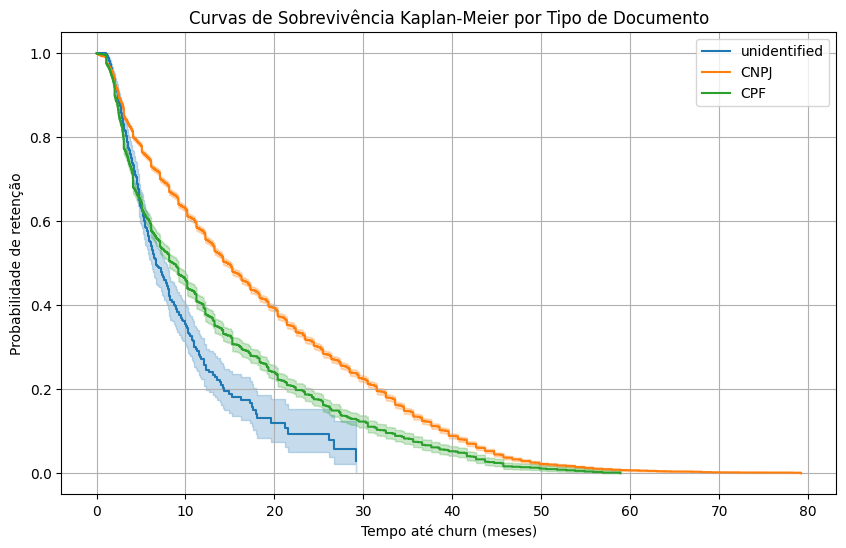

Log-Rank Test CPF vs CNPJ - p-value: 0.0000000
Log-Rank Test Unidentified vs CNPJ - p-value: 0.0000000
Log-Rank Test CPF vs Unidentified - p-value: 0.0040864


In [ ]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Configurar BigQuery
project_id = "name_projeto"
client = bigquery.Client(project=project_id)

# Query para extrair os dados
query = """
SELECT DISTINCT
    company_id,
    company_name,
    company_lifecycle_stage,
    cohort_month,
    churn_date,
    document_type,
    ativo
FROM `customer_experience.sales_retention_study`
"""
df = client.query(query).to_dataframe()

# Converter datas para datetime
df["cohort_month"] = pd.to_datetime(df["cohort_month"])
df["churn_date"] = pd.to_datetime(df["churn_date"])
df["current_date"] = pd.Timestamp.today().normalize()

# Calcular tempo até churn (em meses)
df["tempo_ate_churn"] = np.where(
    df["churn_date"].notna(),
    (df["churn_date"] - df["cohort_month"]).dt.days / 30,
    (df["current_date"] - df["cohort_month"]).dt.days / 30  # Clientes ainda ativos
)

# Filtrar apenas valores onde tempo_ate_churn >= 0
df = df[df["tempo_ate_churn"] >= 0]

# Remover valores NaN
df = df.dropna(subset=["tempo_ate_churn", "ativo", "document_type"])

# Criar um Kaplan-Meier Fitter para cada grupo
kmf = KaplanMeierFitter()

plt.figure(figsize=(10, 6))

# Criar curvas de sobrevivência para cada tipo de documento
for doc_type in df["document_type"].unique():
    mask = df["document_type"] == doc_type
    kmf.fit(df.loc[mask, "tempo_ate_churn"], event_observed=df.loc[mask, "ativo"], label=doc_type)
    kmf.plot_survival_function()

plt.title("Curvas de Sobrevivência Kaplan-Meier por Tipo de Documento")
plt.xlabel("Tempo até churn (meses)")
plt.ylabel("Probabilidade de retenção")
plt.legend()
plt.grid()
plt.show()

# Realizar o teste log-rank para comparar os grupos
cpf = df[df["document_type"] == "CPF"]
cnpj = df[df["document_type"] == "CNPJ"]
unidentified = df[df["document_type"] == "unidentified"]

# Teste log-rank entre CPF e CNPJ
logrank_cpf_cnpj = logrank_test(
    cpf["tempo_ate_churn"], cnpj["tempo_ate_churn"],
    event_observed_A=cpf["ativo"], event_observed_B=cnpj["ativo"]
)
print(f"Log-Rank Test CPF vs CNPJ - p-value: {logrank_cpf_cnpj.p_value:.7f}")

# Teste log-rank entre Unidentified e CNPJ
logrank_unid_cnpj = logrank_test(
    unidentified["tempo_ate_churn"], cnpj["tempo_ate_churn"],
    event_observed_A=unidentified["ativo"], event_observed_B=cnpj["ativo"]
)
print(f"Log-Rank Test Unidentified vs CNPJ - p-value: {logrank_unid_cnpj.p_value:.7f}")

# Teste log-rank entre CPF e Unidentified
logrank_cpf_unid = logrank_test(
    cpf["tempo_ate_churn"], unidentified["tempo_ate_churn"],
    event_observed_A=cpf["ativo"], event_observed_B=unidentified["ativo"]
)
print(f"Log-Rank Test CPF vs Unidentified - p-value: {logrank_cpf_unid.p_value:.7f}")


📊 Modelo Weibull - Resumo dos Coeficientes:


<lifelines.WeibullAFTFitter: fitted with 26534 total observations, 9925 right-censored observations>
             duration col = 'tempo_ate_churn'
                event col = 'ativo'
   number of observations = 26534
number of events observed = 16609
           log-likelihood = -64357.31
         time fit was run = 2025-04-03 21:14:45 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                     
lambda_ CPF          -0.38      0.68      0.02           -0.42           -0.35                0.66                0.70
        Unidentified -0.63      0.53      0.05           -0.72           -0.54                0.49                0.58
        Intercept     2.97     19.51      0.01            2.96            2.99               19.22               19.79
rho_    Intercept     0.15      1.16      0.01            0.14            0.16                1.15                1.18

                      cmp to      z      p  -log2(p)
param   covariate                                   
lambda_ CPF             0.00 -21.95 <0.005    352.35
        Unidentified    0.00 -13.76 <0.005    140.71
        Intercept       0.00 397.94 <0.005       inf
rho_    Intercept       0.00  25.60 <0.005    477.85
---
Concordance = 0.54
AIC = 128722.61
log-likelihood ratio test = 554.72 on 2 df
-log2(p) of ll-ratio test = 400.15

None

📊 Modelo Log-Normal - Resumo dos Coeficientes:


<lifelines.LogNormalAFTFitter: fitted with 26534 total observations, 9925 right-censored observations>
             duration col = 'tempo_ate_churn'
                event col = 'ativo'
   number of observations = 26534
number of events observed = 16609
           log-likelihood = -64686.88
         time fit was run = 2025-04-03 21:14:46 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                     
mu_    CPF          -0.39      0.68      0.02           -0.43           -0.35                0.65                0.71
       Unidentified -0.43      0.65      0.05           -0.52           -0.33                0.59                0.72
       Intercept     2.52     12.41      0.01            2.50            2.54               12.20               12.63
sigma_ Intercept     0.13      1.13      0.01            0.12            0.14                1.12                1.15

                     cmp to      z      p  -log2(p)
param  covariate                                   
mu_    CPF             0.00 -19.18 <0.005    270.04
       Unidentified    0.00  -8.65 <0.005     57.40
       Intercept       0.00 282.99 <0.005       inf
sigma_ Intercept       0.00  23.05 <0.005    387.98
---
Concordance = 0.54
AIC = 129381.76
log-likelihood ratio test = 409.46 on 2 df
-log2(p) of ll-ratio test = 295.36

None


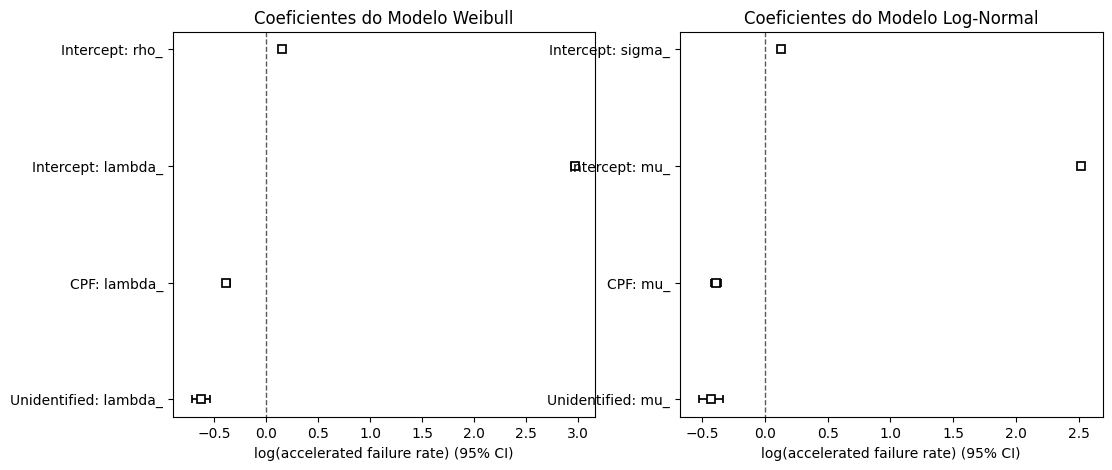

In [ ]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import WeibullAFTFitter, LogNormalAFTFitter

# Configurar BigQuery
project_id = "name_projeto"
client = bigquery.Client(project=project_id)

# Query para extrair os dados
query = """
SELECT DISTINCT
    company_id,
    company_name,
    company_lifecycle_stage,
    cohort_month,
    churn_date,
    document_type,
    ativo
FROM `customer_experience.sales_retention_study`
"""
df = client.query(query).to_dataframe()

# Converter datas para datetime
df["cohort_month"] = pd.to_datetime(df["cohort_month"])
df["churn_date"] = pd.to_datetime(df["churn_date"])
df["current_date"] = pd.Timestamp.today().normalize()

# Calcular tempo até churn (em meses)
df["tempo_ate_churn"] = np.where(
    df["churn_date"].notna(),
    (df["churn_date"] - df["cohort_month"]).dt.days / 30,
    (df["current_date"] - df["cohort_month"]).dt.days / 30  # Clientes ainda ativos
)

# 🔹 Manter apenas valores onde tempo_ate_churn > 0
df = df[df["tempo_ate_churn"] > 0]

# Remover valores NaN
df = df.dropna(subset=["tempo_ate_churn", "ativo", "document_type"])

# Criar variáveis dummies para document_type
df = pd.get_dummies(df, columns=["document_type"], drop_first=False)
df.rename(columns={
    "document_type_CPF": "CPF",
    "document_type_unidentified": "Unidentified",
    "document_type_CNPJ": "CNPJ"
}, inplace=True)

# Ajustar para garantir que CNPJ seja a referência (remover a coluna dele)
df.drop(columns=["CNPJ"], inplace=True)  # Agora todas as comparações são contra CNPJ

# Criar dataframe do modelo
df_model = df[["tempo_ate_churn", "ativo", "CPF", "Unidentified"]]

# 📌 Modelo de Regressão Paramétrica - Weibull
weibull_model = WeibullAFTFitter()
weibull_model.fit(df_model, duration_col="tempo_ate_churn", event_col="ativo")
print("📊 Modelo Weibull - Resumo dos Coeficientes:")
print(weibull_model.print_summary(decimals=2))

# 📌 Modelo de Regressão Paramétrica - Log-Normal
lognormal_model = LogNormalAFTFitter()
lognormal_model.fit(df_model, duration_col="tempo_ate_churn", event_col="ativo")
print("\n📊 Modelo Log-Normal - Resumo dos Coeficientes:")
print(lognormal_model.print_summary(decimals=2))

# 📊 Plotar os coeficientes dos modelos
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
weibull_model.plot()
plt.title("Coeficientes do Modelo Weibull")

plt.subplot(1, 2, 2)
lognormal_model.plot()
plt.title("Coeficientes do Modelo Log-Normal")
plt.subplots_adjust()
plt.show()



In [ ]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
! pip install lifelines
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

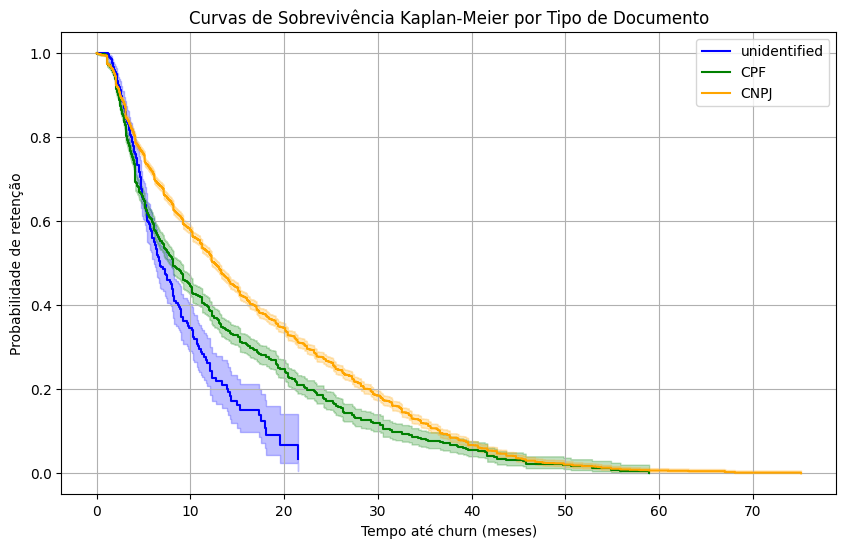

Log-Rank Test CPF vs CNPJ - p-value: 0.0000000
Log-Rank Test Unidentified vs CNPJ - p-value: 0.0000000
Log-Rank Test CPF vs Unidentified - p-value: 0.0086558


In [ ]:
# Configurar BigQuery
project_id = "name_projeto"
client = bigquery.Client(project=project_id)

# Query para extrair os dados
query = """
SELECT DISTINCT
    company_id,
    company_name,
    company_lifecycle_stage,
    cohort_month,
    churn_date,
    document_type,
    ativo
FROM `customer_experience.sales_retention_study`
Where avg_gmv <20000
"""
df = client.query(query).to_dataframe()

# Converter datas para datetime
df["cohort_month"] = pd.to_datetime(df["cohort_month"])
df["churn_date"] = pd.to_datetime(df["churn_date"])
df["current_date"] = pd.Timestamp.today().normalize()

# Calcular tempo até churn (em meses)
df["tempo_ate_churn"] = np.where(
    df["churn_date"].notna(),
    (df["churn_date"] - df["cohort_month"]).dt.days / 30,
    (df["current_date"] - df["cohort_month"]).dt.days / 30  # Clientes ainda ativos
)

# Filtrar apenas valores onde tempo_ate_churn >= 0
df = df[df["tempo_ate_churn"] >= 0]

# Remover valores NaN
df = df.dropna(subset=["tempo_ate_churn", "ativo", "category_time_for_hours"])

# Criar um Kaplan-Meier Fitter para cada grupo
kmf = KaplanMeierFitter()
color_map = {
    "unidentified": "blue",
    "CPF": "green",
    "CNPJ": "orange"
}

plt.figure(figsize=(10, 6))

# Criar curvas de sobrevivência para cada tipo de documento
for doc_type in df["category_time_for_hours"].unique():
    mask = df["category_time_for_hours"] == doc_type
    kmf.fit(df.loc[mask, "tempo_ate_churn"], event_observed=df.loc[mask, "ativo"], label=doc_type)
    kmf.plot_survival_function(color=color_map.get(doc_type, "gray"))

plt.title("Curvas de Sobrevivência Kaplan-Meier por category_time_for_hours")
plt.xlabel("Tempo até churn (meses)")
plt.ylabel("Probabilidade de retenção")
plt.legend()
plt.grid()
plt.show()

# Realizar o teste log-rank para comparar os grupos
cpf = df[df["document_type"] == "CPF"]
cnpj = df[df["document_type"] == "CNPJ"]
unidentified = df[df["document_type"] == "unidentified"]

# Teste log-rank entre CPF e CNPJ
logrank_cpf_cnpj = logrank_test(
    cpf["tempo_ate_churn"], cnpj["tempo_ate_churn"],
    event_observed_A=cpf["ativo"], event_observed_B=cnpj["ativo"]
)
print(f"Log-Rank Test CPF vs CNPJ - p-value: {logrank_cpf_cnpj.p_value:.7f}")

# Teste log-rank entre Unidentified e CNPJ
logrank_unid_cnpj = logrank_test(
    unidentified["tempo_ate_churn"], cnpj["tempo_ate_churn"],
    event_observed_A=unidentified["ativo"], event_observed_B=cnpj["ativo"]
)
print(f"Log-Rank Test Unidentified vs CNPJ - p-value: {logrank_unid_cnpj.p_value:.7f}")

# Teste log-rank entre CPF e Unidentified
logrank_cpf_unid = logrank_test(
    cpf["tempo_ate_churn"], unidentified["tempo_ate_churn"],
    event_observed_A=cpf["ativo"], event_observed_B=unidentified["ativo"]
)
print(f"Log-Rank Test CPF vs Unidentified - p-value: {logrank_cpf_unid.p_value:.7f}")

In [ ]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter

# Configurar BigQuery
project_id = "name_projeto"
client = bigquery.Client(project=project_id)

# Query para extrair os dados
query = """
SELECT DISTINCT
    company_id,
    company_name,
    company_lifecycle_stage,
    cohort_month,
    churn_date,
    document_type,
    ativo
FROM `customer_experience.sales_retention_study`
Where avg_gmv <20000
"""

df = client.query(query).to_dataframe()

# Converter datas para datetime
df["cohort_month"] = pd.to_datetime(df["cohort_month"])
df["churn_date"] = pd.to_datetime(df["churn_date"])
df["current_date"] = pd.Timestamp.today().normalize()

# Calcular tempo até churn (em meses)
df["tempo_ate_churn"] = np.where(
    df["company_lifecycle_stage"] == "customer",
    (df["current_date"] - df["cohort_month"]).dt.days / 30,
    np.where(
        df["churn_date"].notna(),
        (df["churn_date"] - df["cohort_month"]).dt.days / 30,
        np.nan
    )
)

# Remover valores NaN
df = df.dropna(subset=["tempo_ate_churn", "ativo", "document_type"])

# Converter variável categórica para dummies e definir CNPJ como referência
df = pd.get_dummies(df, columns=["document_type"], drop_first=False)
df.rename(columns={
    "document_type_CPF": "CPF",
    "document_type_unidentified": "Unidentified",
    "document_type_CNPJ": "CNPJ"
}, inplace=True)

# Ajustar para garantir que CNPJ seja a referência (remover a coluna dele)
df.drop(columns=["CNPJ"], inplace=True)  # Agora todas as comparações são contra CNPJ

# Criar modelo de Cox
cph = CoxPHFitter()
cph.fit(df[["tempo_ate_churn", "ativo", "CPF", "Unidentified"]], duration_col="tempo_ate_churn", event_col="ativo")

# Exibir resultados com duas casas decimais
cph.print_summary(decimals=2)

# Plotar coeficientes do modelo
cph.plot()
plt.show()


ModuleNotFoundError: No module named 'lifelines'